# Avaliação — VessMap

Notebook fino reusando `utils_eval.py` (loader unificado) e `utils.py` (plot/aggregação legado).

**Observação:** Zero-shot real (CSV existente). Scratch + 5 finetune variants disponíveis.

## Legenda das nomenclaturas de modelos

Cada `model_type` codifica três informações: **arquitetura**, **origem dos pesos iniciais** e **regime de treino**.

| Label                     | Arquitetura                                     | Pesos iniciais                                       | Regime                                  | Stage       |
|---------------------------|-------------------------------------------------|------------------------------------------------------|-----------------------------------------|-------------|
| `UNet18`                  | U-Net (encoder ResNet-18)                       | Aleatórios (Kaiming)                                 | Treino do zero                          | `scratch`   |
| `UNet50`                  | U-Net (encoder ResNet-50)                       | Aleatórios (Kaiming)                                 | Treino do zero                          | `scratch`   |
| `VSUNet18`                | U-Net (encoder ResNet-18)                       | Pré-treinados em **VessShape**                       | Fine-tuning no dataset alvo             | `finetune`  |
| `VSUNet50`                | U-Net (encoder ResNet-50)                       | Pré-treinados em **VessShape**                       | Fine-tuning no dataset alvo             | `finetune`  |
| `IN-UNet18`               | U-Net (encoder ResNet-18)                       | Pré-treinados em **ImageNet**                        | Fine-tuning no dataset alvo             | `finetune`  |
| `IN-UNet50`               | U-Net (encoder ResNet-50)                       | Pré-treinados em **ImageNet**                        | Fine-tuning no dataset alvo             | `finetune`  |
| `LiteMedSAM-FT`           | LiteMedSAM (encoder ViT leve do MedSAM)         | Pré-treinados em **MedSAM** (LiteMedSAM checkpoint) | Fine-tuning no dataset alvo             | `finetune`  |
| `Zero-Shot VSUNet18`      | U-Net (encoder ResNet-18)                       | Pré-treinados em **VessShape**                       | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot VSUNet50`      | U-Net (encoder ResNet-50)                       | Pré-treinados em **VessShape**                       | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot IN-UNet18`     | U-Net (encoder ResNet-18)                       | Pré-treinados em **ImageNet**                        | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot IN-UNet50`     | U-Net (encoder ResNet-50)                       | Pré-treinados em **ImageNet**                        | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot LiteMedSAM`    | LiteMedSAM (encoder ViT leve do MedSAM)         | Pré-treinados em **MedSAM**                          | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot LiteMedSAM+IN` | LiteMedSAM (encoder ViT leve do MedSAM)         | Pré-treinados em **MedSAM** + norm. ImageNet entrada | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `... (mock)`              | —                                               | —                                                    | Placeholder com `NaN`                   | `zero_shot` |

**Convenções:**
- `VS` = pré-treino em **VessShape** (dataset sintético próprio do projeto).
- `IN-` = pré-treino em **ImageNet**.
- `-FT` = fine-tuning a partir de checkpoint pré-treinado.
- `+IN` = normalização ImageNet aplicada na **entrada** do modelo (`_PreprocessModel` wrapper) — não altera os pesos, só pré-processa o input.
- `Zero-Shot` = nenhum fine-tuning no dataset alvo (`num_samples = 0`); gerado por `run_zero_shot_inference.ipynb`.
- Sufixo ` (mock)` = placeholder (`utils_eval.generate_mock_zero_shot`, `is_mock=True`, `NaN`) usado **apenas** como fallback enquanto o CSV de zero-shot real não existir.

**Eixo de comparação do paper:**
- `UNet*` (scratch) vs `IN-UNet*` (ImageNet) vs `VSUNet*` (VessShape) → mede o ganho do pré-treino em VessShape sobre as alternativas.
- `Zero-Shot *` em `num_samples = 0` (VSUNet / IN-UNet / LiteMedSAM) → mede a transferência sem fine-tuning de cada origem de pesos.
- `LiteMedSAM-FT` → baseline de modelo de segmentação médica de larga escala (com fine-tuning).
- `Zero-Shot LiteMedSAM` vs `Zero-Shot LiteMedSAM+IN` → valida H1 (normalização de entrada): se `+IN` tiver Dice > 0, a normalização ImageNet era necessária para os pesos originais do LiteMedSAM.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from utils_eval import (
    load_dataset_results,
    load_dataset_per_image,
    save_result_matrices,
    build_summary_table,
    default_line_styles_7way,
    report_coverage,
    RESULTS_DIR,
    FIGURES_DIR,
    ensure_output_dirs,
)

ensure_output_dirs()  # cria results/ e figures/ se necessário
from utils import plot_mean_dice_score

## 1. Carregar dados

In [2]:
DATASET = 'vessmap'
MOCK_ZS = False

df = load_dataset_results(DATASET, root='..', mock_zero_shot=MOCK_ZS)
print('shape =', df.shape)
df['model_type'].value_counts()

shape = (1107, 17)


model_type
IN-UNet18               165
LiteMedSAM-FT           165
IN-UNet50               165
VSUNet18                165
VSUNet50                164
UNet50                  143
UNet18                  135
Zero-Shot VSUNet18        1
Zero-Shot VSUNet50        1
Zero-Shot IN-UNet18       1
Zero-Shot IN-UNet50       1
Zero-Shot LiteMedSAM      1
Name: count, dtype: int64

## Matrizes de resultados (intermediárias)

Salvas em `results/` via `save_result_matrices`. Três regimes × duas granularidades:
- `<ds>_few_shot_results[_per_image].csv` — só few-shot (scratch + finetune).
- `<ds>_zero_shot_results[_per_image].csv` — só zero-shot.
- `<ds>_all_results[_per_image].csv` — few + zero-shot (matriz-base).

Granularidade média-por-run (sufixo vazio) e por-imagem (`_per_image`). Zero-shot mock não tem per-image.

In [3]:
# Matriz média-por-run (df já carregado) — few-shot / zero-shot / all
paths_run = save_result_matrices(df, DATASET)

# Matriz por imagem — few-shot / zero-shot / all
df_per_image = load_dataset_per_image(DATASET, root='..')
paths_img = save_result_matrices(df_per_image, DATASET, suffix='_per_image')

print('run-mean :', df.shape, '->', {k: __import__('os').path.basename(v) for k, v in paths_run.items()})
print('per-image:', df_per_image.shape, '->', {k: __import__('os').path.basename(v) for k, v in paths_img.items()})

run-mean : (1107, 17) -> {'few_shot': 'vessmap_few_shot_results.csv', 'zero_shot': 'vessmap_zero_shot_results.csv', 'all': 'vessmap_all_results.csv'}
per-image: (22140, 18) -> {'few_shot': 'vessmap_few_shot_results_per_image.csv', 'zero_shot': 'vessmap_zero_shot_results_per_image.csv', 'all': 'vessmap_all_results_per_image.csv'}


## 2. Sanidade — cobertura por modelo / stage

In [4]:
coverage = report_coverage(df)
print('Stages presentes:', sorted(df['stage'].unique()))
if df['is_mock'].any():
    n_mock = int(df['is_mock'].sum())
    print(f'[INFO] {n_mock} linha(s) zero-shot MOCK (NaN). Substituir quando inferência real estiver pronta.')

expected = {'UNet18','UNet50','VSUNet18','VSUNet50','IN-UNet18','IN-UNet50','LiteMedSAM-FT'}
missing = expected - set(df['model_type'].unique())
if missing:
    print(f'[INFO] model_types ausentes (esperado em datasets completos): {sorted(missing)}')
coverage

Stages presentes: ['finetune', 'scratch', 'zero_shot']


,,count,min,max
model_type,stage,,,
IN-UNet18,finetune,165,1,20
IN-UNet50,finetune,165,1,20
LiteMedSAM-FT,finetune,165,1,20
UNet18,scratch,135,1,20
UNet50,scratch,143,1,20
VSUNet18,finetune,165,1,20
VSUNet50,finetune,164,1,20
Zero-Shot IN-UNet18,zero_shot,1,0,0
Zero-Shot IN-UNet50,zero_shot,1,0,0


## 3. Resumo (mean ± std) em num_samples ∈ [0, 1, 20]

In [5]:
SAMPLE_FILTER = [0, 1, 20]
summary = build_summary_table(df, sample_filter=SAMPLE_FILTER)
summary.to_csv(os.path.join(RESULTS_DIR, 'vessmap_results_summary.csv'), index=False)
summary

,model_type,num_samples,mean_Accuracy,std_Accuracy,mean_IoU,std_IoU,mean_Precision,std_Precision,mean_Recall,std_Recall,mean_Dice,std_Dice,mean_AUC,std_AUC
0,IN-UNet18,1,0.651133,0.154921,0.357602,0.078854,0.586141,0.187395,0.660827,0.179978,0.485583,0.082485,0.781195,0.086924
1,IN-UNet18,20,0.922932,0.010348,0.713157,0.036758,0.863449,0.030091,0.811081,0.061219,0.822028,0.029491,0.965223,0.005488
2,IN-UNet50,1,0.666781,0.223678,0.402879,0.090024,0.627195,0.225403,0.711557,0.168689,0.534322,0.086542,0.840877,0.039321
3,IN-UNet50,20,0.932008,0.009469,0.740701,0.016660,0.884297,0.031945,0.821307,0.038949,0.841621,0.014071,0.969103,0.003391
4,LiteMedSAM-FT,1,0.754637,0.213352,0.458689,0.125835,0.690520,0.214464,0.671937,0.168473,0.581172,0.117465,0.833197,0.131980
5,LiteMedSAM-FT,20,0.952640,0.002832,0.818412,0.007954,0.884509,0.018815,0.918060,0.014259,0.895343,0.006437,0.985772,0.001913
6,UNet18,1,0.632563,0.199154,0.361781,0.062546,0.591546,0.190815,0.701983,0.166470,0.491454,0.059904,0.803918,0.095950
7,UNet18,20,0.915816,0.011096,0.720393,0.029375,0.812641,0.026776,0.869807,0.059887,0.830410,0.023529,0.970327,0.005398
8,UNet50,1,0.593880,0.215568,0.347888,0.067938,0.554332,0.202465,0.728329,0.175741,0.480361,0.065442,0.781580,0.077661
9,UNet50,20,0.879358,0.020493,0.594771,0.050734,0.843224,0.038998,0.701132,0.068504,0.725759,0.043844,0.925841,0.016988


## 3a. Resumo few-shot (scratch + finetune)

In [ ]:
df_fs = df[df['stage'] != 'zero_shot']
summary_fs = build_summary_table(df_fs, sample_filter=[s for s in SAMPLE_FILTER if s > 0])
summary_fs

## 3b. Resumo zero-shot (N=0)

In [ ]:
df_zs = df[(df['stage'] == 'zero_shot') & (~df['is_mock'])]
if df_zs.empty:
    print('[INFO] Sem dados zero-shot reais.')
else:
    summary_zs = (df_zs
                  .groupby('model_type')[['Dice', 'IoU', 'Precision', 'Recall', 'AUC']]
                  .mean()
                  .sort_values('Dice', ascending=False))
    summary_zs

## 4. Plot principal — Dice por # samples

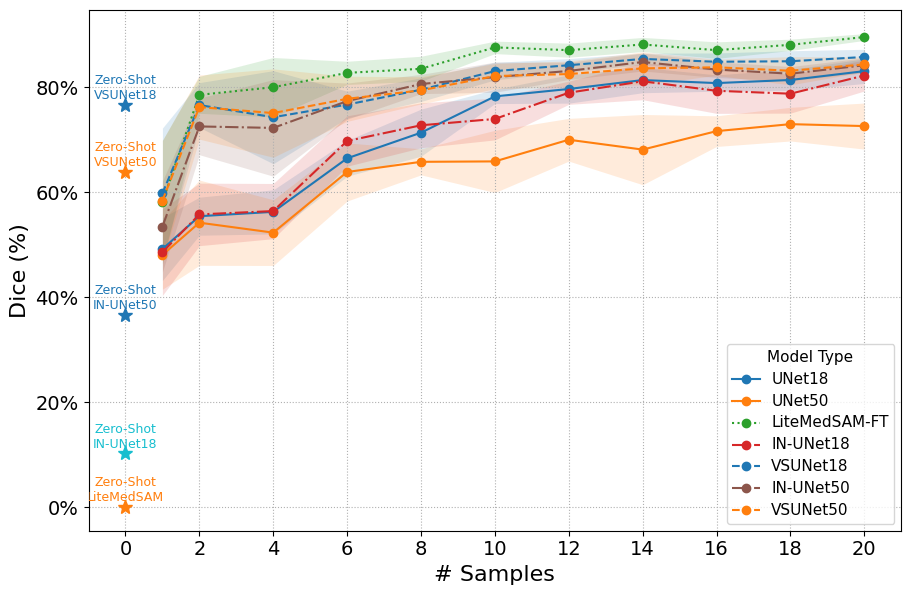

In [6]:
line_styles = default_line_styles_7way()

plot_mean_dice_score(
    df,
    dataset_name='VessMap',
    hue='model_type',
    x_data='num_samples',
    y_data='Dice',
    line_styles=line_styles,
    annotate_zero_shot=True,
    title='',
    legend_title='Model Type',
    xlabel='# Samples',
    percentage=True,
    save_path=os.path.join(FIGURES_DIR, 'vessmap.svg'),
    font_sizes={
        'title': 16,
        'xlabel': 16,
        'ylabel': 16,
        'xaxis': 14,
        'yaxis': 14,
        'legend': 11,
        'zero_shot_annotation': 9,
        'zero_shot_marker': 10,
    },
    figsize=(9, 6),
    legend_loc='lower right',
    share_zero_shot_color_with='finetuned',
)

## 5. Subplots focados — família ResNet18 e ResNet50

In [ ]:
for fam_name, fam_labels in [
    ('ResNet18', ['UNet18','VSUNet18','IN-UNet18','Zero-Shot VSUNet18','Zero-Shot IN-UNet18','Zero-Shot VSUNet18 (mock)']),
    ('ResNet50', ['UNet50','VSUNet50','IN-UNet50','Zero-Shot VSUNet50','Zero-Shot IN-UNet50','Zero-Shot VSUNet50 (mock)']),
    ('LiteMedSAM', ['LiteMedSAM-FT', 'Zero-Shot LiteMedSAM', 'Zero-Shot LiteMedSAM+IN']),
]:
    sub = df[df['model_type'].isin(fam_labels)]
    if sub.empty:
        print(f'[INFO] Sem dados para {fam_name}.')
        continue
    plot_mean_dice_score(
        sub,
        dataset_name='VessMap — ' + fam_name,
        hue='model_type',
        x_data='num_samples',
        y_data='Dice',
        line_styles=line_styles,
        annotate_zero_shot=True,
        legend_title='Model Type',
        xlabel='# Samples',
        percentage=True,
        save_path=os.path.join(FIGURES_DIR, 'vessmap_' + fam_name.lower() + '.svg'),
        figsize=(8, 5.5),
        legend_loc='lower right',
        share_zero_shot_color_with='finetuned',
    )